In [ ]:
import json
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append("/user/christoph.wald/u15287/insect_pest_detection/modules")
from modules_segmentation import *


In [ ]:
# Load the JSON file
with open("/user/christoph.wald/u15287/insect_pest_detection/2_5_self_training/results.json", "r") as f:
    data = json.load(f)

#boxes in xyxy-format
box = data[0]["false_negatives"]["boxes"][1]
box

Number of entries: 211
Filename: BRAIIM_0157.jpg
Number of true positive boxes: 25
First TP box: [543.184326171875, 552.3759765625, 688.068603515625, 690.93212890625]


In [ ]:
def compute_mask_coverage(mask, rectangles, threshold=0.2):
    """
    mask: np.ndarray (grayscale, same size as original image)
    rectangles: list of rectangles [(x_min, y_min, x_max, y_max), ...]
    Returns: list of (rect_idx, coverage_ratio, is_covered)
    """
    results = []
    for i, (x1, y1, x2, y2) in enumerate(rectangles):
        #x2 = x1 + w
        #y2 = y1 + h
        # Ensure bounds within image
        x1, y1 = max(0, int(x1)), max(0, int(y1))
        x2, y2 = min(mask.shape[1], int(x2)), min(mask.shape[0], int(y2))
        if x2 <= x1 or y2 <= y1:
            results.append((i, 0.0, False))
            continue

        # Extract mask region
        region = mask[y1:y2, x1:x2]

        # Count masked pixels (assuming 0=masked, 255=background)
        masked_pixels = np.sum(region == 0)
        total_pixels = region.size
        ratio = masked_pixels / total_pixels

        is_covered = ratio >= threshold
        results.append((i, ratio, is_covered))
    return results

In [124]:
image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/02_images_rotated"
label_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/02_labels_rotated"

processed_mask = cv2.imread(
    "/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/06_generated_mask_fat_plus.jpg", 
    cv2.IMREAD_GRAYSCALE
)

gridcorners = np.load("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/gridcorners.npy")
mask_h_line = np.load("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/mask_h_line.npy")

image_files = os.listdir(image_folder)

with open("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/logs/rotated_files_test_set.txt", "r") as f:
    files_rotated = set(line.strip() for line in f)

In [96]:
def get_mask(image_file):
    #Load image file
    print(f"Loading {image_file}")
    image = cv2.imread(os.path.join(image_folder, image_file))

    #find YST contour of image
    imageYST = find_contour(image)

    #save cropped image
    x, y, w, h = cv2.boundingRect(imageYST)
    

    #find corners if possible, if not skip the image
    imagecorners = find_corners(image, imageYST)
    if len(imagecorners) == 0:
        print(f"No YST found for {image_file}")
        return None

    #find transformation
    H, _ = cv2.findHomography(gridcorners, imagecorners, cv2.RANSAC)

    #first transformation: 
    mask = cv2.warpPerspective(processed_mask, H, (image.shape[1], image.shape[0]))
    
    #transform midline of mask as above
    h_line_pts = mask_h_line.reshape(-1,1,2)
    h_line_pts_warped = cv2.perspectiveTransform(h_line_pts, H)
    x1w, y1w, x2w, y2w = h_line_pts_warped.reshape(-1).astype(np.int32)
    mask_h = (x1w, y1w, x2w, y2w)

    #second transformation: correct vertical misalignment
    image_h = get_h_mid(create_binary_mask(image))
    dy = get_midpoint(image_h)- get_midpoint(mask_h)
    print (dy)
    if abs(dy) > 500:
        print(f"Skipped vertical alignment, wrong horizontal line with offset {dy}")
    else:
        H, W = mask.shape[:2]
        M = np.float32([[1, 0, 0], [0, 1, dy]])  # translation matrix
        mask= cv2.warpAffine(mask, M, (W, H), borderValue=255)  # white background
    return mask[y:y+h, x:x+w]

In [97]:
f = data[1]["filename"]

In [ ]:
mask = get_mask(f)
if f in files_rotated:
    print("Rotate mask")
    mask = cv2.rotate(mask, cv2.ROTATE_180)

Loading BRAIIM_0170.jpg
using only simple binarization.
using only simple binarization.


113.0


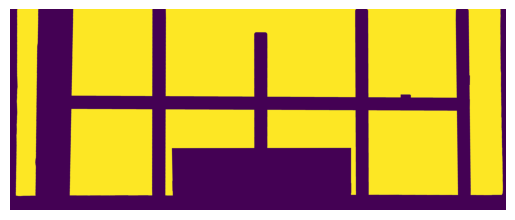

In [103]:
plt.imshow(mask)
plt.axis("off")
plt.show()

In [105]:
r = data[1]["false_negatives"]["boxes"]
overlaps = compute_mask_coverage(mask, r)
overlaps

[(0, np.float64(0.8309535658232209), np.True_),
 (1, np.float64(0.06650488770861473), np.False_),
 (2, np.float64(0.5779560439560439), np.True_),
 (3, np.float64(1.0), np.True_),
 (4, np.float64(1.0), np.True_),
 (5, np.float64(1.0), np.True_),
 (6, np.float64(0.0), np.False_),
 (7, np.float64(0.7418181818181818), np.True_),
 (8, np.float64(0.5117797695262484), np.True_),
 (9, np.float64(0.0), np.False_),
 (10, np.float64(1.0), np.True_),
 (11, np.float64(1.0), np.True_),
 (12, np.float64(0.22002571520411443), np.True_),
 (13, np.float64(0.0), np.False_),
 (14, np.float64(0.9725274725274725), np.True_),
 (15, np.float64(1.0), np.True_),
 (16, np.float64(0.8035714285714286), np.True_),
 (17, np.float64(1.0), np.True_),
 (18, np.float64(0.1717171717171717), np.False_)]

In [108]:
if overlaps[0][2]:
    print("True")

True


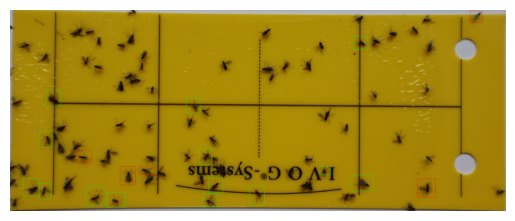

In [116]:
image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/images"
img_copy = cv2.imread(os.path.join(image_folder, f))
for i, box in enumerate(r):
    x1,y1,x2,y2 = map (int, box)
    if overlaps[i][2]:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 255, 0), thickness=2)
    else:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 0, 255), thickness=2)

img_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

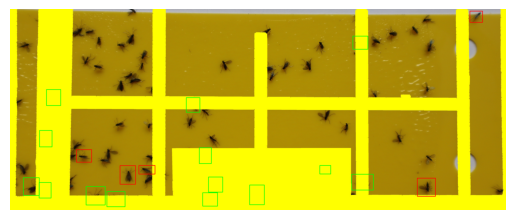

In [118]:

image_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/test_set/SSL/03_images_masked"
img_copy = cv2.imread(os.path.join(image_folder, f))
if f in files_rotated:
    img_copy = cv2.rotate(img_copy, cv2.ROTATE_180)

for i, box in enumerate(r):
    x1,y1,x2,y2 = map (int, box)
    if overlaps[i][2]:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 255, 0), thickness=5)
    else:
        cv2.rectangle(img_copy, (x1, y1), (x2,y2), color=(0, 0, 255), thickness=5)

img_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [136]:
true_count = 0
false_count = 0
unchecked = 0
for d in data:
    f = d["filename"]
    r = d["false_negatives"]["boxes"]
    mask = get_mask(f)
    if mask is None:
        unchecked += len(r)
        continue
    if f in files_rotated:
        print("Rotate mask")
        mask = cv2.rotate(mask, cv2.ROTATE_180)
    overlaps = compute_mask_coverage(mask, r)
    true_count += sum(1 for _, _, val in overlaps if val)
    false_count += sum(1 for _, _, val in overlaps if not val)
print(f"True {true_count}")
print(f"False {false_count}")
print(f"Remaining {unchecked}")

Loading BRAIIM_0157.jpg
using only simple binarization.
No YST found for BRAIIM_0157.jpg
Loading BRAIIM_0170.jpg
using only simple binarization.
using only simple binarization.
113.0
Rotate mask
Loading BRAIIM_0184.jpg
using only simple binarization.
using only simple binarization.
94.0
Rotate mask
Loading BRAIIM_0195.jpg
using only simple binarization.
No YST found for BRAIIM_0195.jpg
Loading BRAIIM_0204.jpg
using only simple binarization.
using only simple binarization.
101.0
Rotate mask
Loading BRAIIM_0207.jpg
using only simple binarization.
using only simple binarization.
84.0
Rotate mask
Loading BRAIIM_0223.jpg
using only simple binarization.
using only simple binarization.
30.0
Rotate mask
Loading BRAIIM_0286.jpg
using only simple binarization.
using only simple binarization.
33.5
Rotate mask
Loading BRAIIM_0288.jpg
using only simple binarization.
using only simple binarization.
54.0
Rotate mask
Loading BRAIIM_0302.jpg
using only simple binarization.
using only simple binarizatio

In [133]:
overlaps

[(0, np.float64(0.8309535658232209), np.True_),
 (1, np.float64(0.06650488770861473), np.False_),
 (2, np.float64(0.5779560439560439), np.True_),
 (3, np.float64(1.0), np.True_),
 (4, np.float64(1.0), np.True_),
 (5, np.float64(1.0), np.True_),
 (6, np.float64(0.0), np.False_),
 (7, np.float64(0.7418181818181818), np.True_),
 (8, np.float64(0.5117797695262484), np.True_),
 (9, np.float64(0.0), np.False_),
 (10, np.float64(1.0), np.True_),
 (11, np.float64(1.0), np.True_),
 (12, np.float64(0.22002571520411443), np.True_),
 (13, np.float64(0.0), np.False_),
 (14, np.float64(0.9725274725274725), np.True_),
 (15, np.float64(1.0), np.True_),
 (16, np.float64(0.8035714285714286), np.True_),
 (17, np.float64(1.0), np.True_),
 (18, np.float64(0.1717171717171717), np.False_)]

In [137]:
from collections import defaultdict
import cv2
import os

# Initialize per-class counters
stats = defaultdict(lambda: {"true": 0, "false": 0, "unchecked": 0})

for d in data:
    f = d["filename"]

    # Determine class from filename prefix
    if f.startswith("BRAIIM"):
        cls = "BRAIIM"
    elif f.startswith("LIRIBO"):
        cls = "LIRIBO"
    elif f.startswith("TRIAVA"):
        cls = "TRIAVA"
    else:
        cls = "UNKNOWN"

    r = d["false_negatives"]["boxes"]
    mask = get_mask(f)

    if mask is None:
        stats[cls]["unchecked"] += len(r)
        continue

    if f in files_rotated:
        print(f"Rotate mask for {f}")
        mask = cv2.rotate(mask, cv2.ROTATE_180)

    overlaps = compute_mask_coverage(mask, r)

    stats[cls]["true"] += sum(1 for _, _, val in overlaps if val)
    stats[cls]["false"] += sum(1 for _, _, val in overlaps if not val)

# Print per-class results
for cls, counts in stats.items():
    print(f"\nClass: {cls}")
    print(f"  True:      {counts['true']}")
    print(f"  False:     {counts['false']}")
    print(f"  Unchecked: {counts['unchecked']}")

# Optional: total summary
total_true = sum(c["true"] for c in stats.values())
total_false = sum(c["false"] for c in stats.values())
total_unchecked = sum(c["unchecked"] for c in stats.values())

print("\nOverall totals:")
print(f"  True:      {total_true}")
print(f"  False:     {total_false}")
print(f"  Unchecked: {total_unchecked}")


Loading BRAIIM_0157.jpg
using only simple binarization.
No YST found for BRAIIM_0157.jpg
Loading BRAIIM_0170.jpg
using only simple binarization.
using only simple binarization.
113.0
Rotate mask for BRAIIM_0170.jpg
Loading BRAIIM_0184.jpg
using only simple binarization.
using only simple binarization.
94.0
Rotate mask for BRAIIM_0184.jpg
Loading BRAIIM_0195.jpg
using only simple binarization.
No YST found for BRAIIM_0195.jpg
Loading BRAIIM_0204.jpg
using only simple binarization.
using only simple binarization.
101.0
Rotate mask for BRAIIM_0204.jpg
Loading BRAIIM_0207.jpg
using only simple binarization.
using only simple binarization.
84.0
Rotate mask for BRAIIM_0207.jpg
Loading BRAIIM_0223.jpg
using only simple binarization.
using only simple binarization.
30.0
Rotate mask for BRAIIM_0223.jpg
Loading BRAIIM_0286.jpg
using only simple binarization.
using only simple binarization.
33.5
Rotate mask for BRAIIM_0286.jpg
Loading BRAIIM_0288.jpg
using only simple binarization.
using only sim

In [138]:
stats

defaultdict(<function __main__.<lambda>()>,
            {'BRAIIM': {'true': 372, 'false': 69, 'unchecked': 93},
             'LIRIBO': {'true': 154, 'false': 57, 'unchecked': 19},
             'TRIAVA': {'true': 903, 'false': 878, 'unchecked': 69}})

In [ ]:
BRAIIM recall 0.87
LIRIBO recall 0.93
TRAIVA recall 0.45
